# Micrograd — Karpathy's Zero to Hero, Lecture 1

Building a tiny autograd engine from scratch.

In [79]:
import math
from graphviz import Digraph
import random 

## What is a Value?

A Value is NOT just a number.

It stores:
- data
- grad
- parents (`_prev`)
- operation that created it (`_op`)

Therefore every `Value` object is a node in the computation graph.

In [311]:
#building value object


class Value:

    def __init__(self, data, _children = (), _op='', label = ''):
        self.data = data
        self.grad = 0
        self._prev = set(_children)
        self._backward = lambda :None # acts as a blank for the eventual backprop code for that node.
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value (other) # WHAT IS ISINSTANCE CLAUDEEEEEEEEEEEEEEEEEE
        out = Value(self.data + other.data, (self,other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
            
        out._backward = _backward
        
        return out 
    def __radd__(self,other):
        out = self+other
        return out

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value (other) # WHAT IS ISINSTANCE CLAUDEEEEEEEEEEEEEEEEEE
        out = Value(self.data * other.data, (self,other),'*')
        def _backward ():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 
        
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other, (int,float) ), 'only supporting int/float powers for now ' 
        out = Value (self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other *self.data **(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self,other):
        return self *other

    def __truediv__(self,other):
        return self * other **-1      #dont need .data cuz u defined the constituent operations alrd. 


    def __neg__ (self):
        return self * -1

   

    def __sub__(self,other):
        return (self + (- other))

    def tanh(self):
        x= self.data
        t= (math.exp(2*x) -1) /(math.exp(2*x) +1)
        out = Value(t,(self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) *out.grad

        out._backward = _backward 
        
        return out

    def exp(self):
        x=self.data
        out = Value (math.exp(x), (self,), 'exp')
        
        def _backward ():
            self.grad +=  out.data * out.grad   #to find this out we only consider the case where self.data is an actual value and not some variable with x.
        out._backward = _backward

        return out


    def backward (self):       #what does this do. 
        topo = []
        visited = set () # keeps track of which nodes r visited so that u know what the topological ordering is 
        
        def build_topo(v): #build the topology to get order of backprop
            if v not in visited:            # When you run through this function to reach parent's parents you dont want to re take down its name. 
                visited.add(v)              # the first time u see the node u list it down in the set. This filters out which node needs to BP first.
                for child in v._prev:       # iterates through the parents of that node cuz its the next layer after the node which has been taken down.
                    build_topo(child)       # continues checking the parent's parents and adds it to the list. eventually u get to the bottom and those are the inputs which
                                            # will become the last variables inside the list. 
                topo.append(v)              # basically makes it such that the list appends whatever is the input nodes first so u end up with output end layer nodes at end
        build_topo(self)
        self.grad = 1.0      #why do u do this. shouldnt u only define this if it is the L. or is it L = 1.0 and the others might be assigned this as well but the next part where for node in reveresd, the _backward function assigns the correct dL/dnode

       
        
        for node in reversed (topo):
            node._backward()

        



In [60]:
a = Value (2.0)
2*a

Value(data=4.0)

## Graphviz helper

Traces the graph starting from a root `Value` and renders it left-to-right.

In [61]:
def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (
                n.label, n.data, n.grad
            ),
            shape='record'
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## Neuron example

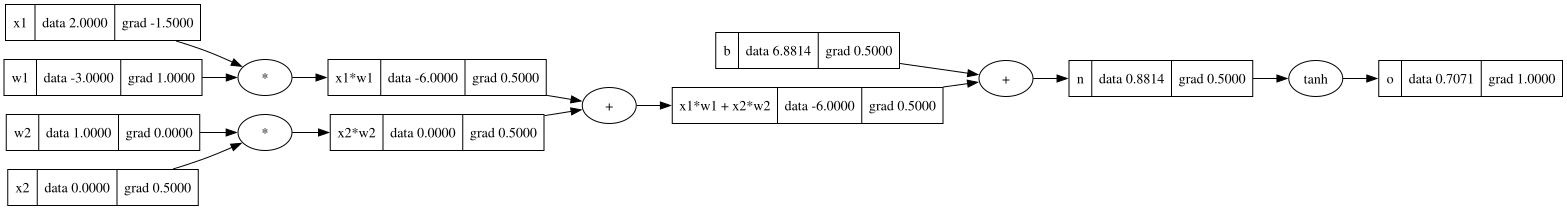

In [62]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# weighted inputs
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

# weighted sum
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

# add bias
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

o.backward()
draw_dot(o)

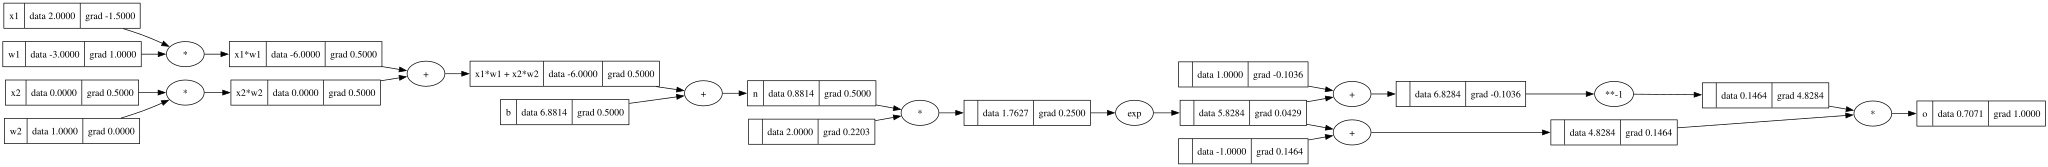

In [63]:
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# weighted inputs
x1w1 = x1 * w1
x1w1.label = 'x1*w1'

x2w2 = x2 * w2
x2w2.label = 'x2*w2'

# weighted sum
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1*w1 + x2*w2'

# add bias
n = x1w1x2w2 + b
n.label = 'n'

# ---------
e= (2*n).exp()
o = (e - 1)/(e+1)
o.label = 'o'
# ---------

o.backward()
draw_dot(o)

In [75]:
import torch

x1 = torch.Tensor([2.0]).double ()                 ; x1.requires_grad = True 
x2 = torch.Tensor([0.0]).double   ()              ; x2.requires_grad = True 
w1 = torch.Tensor([-3.0]).double    ()            ; w1.requires_grad = True 
w2 = torch.Tensor([1.0]).double       ()          ; w2.requires_grad = True 
b = torch.Tensor([6.8813735980195432]).double() ; b.requires_grad = True
n = x1*w1 +x2*w2 + b
o = torch.tanh(n)   # r u squishing every scalar value inside the tensor?

print (o.data.item())
o.backward()  #Backprop through every scalar in each node which contains a tensor full of scalars?

print ('---')
print ('x2',x2.grad.item())
print ('w2',w2.grad.item())
print ('x1',x1.grad.item())
print ('w1',w1.grad.item())








0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [150]:
#building neural net 2 layer multi layer perceptron ?!?!??!
#this subscribes to pytorch api in how it designs its neural network modules

class Neuron:
    def __init__(self,nin):
        # based on no. of inputs creates a linear list of weight for every input
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]  
        self.b = Value (random.uniform(-1,1))       #random bias that controls the overall triger happiness of the neuron

    def __call__(self,x):
        #w *x +b
        act = sum ( (wi*xi for wi,xi in zip(self.w,x)), self.b) 
        out = act.tanh()
        return out

class Layer:
        # nout is the no. of neurons in a layer 
    def __init__(self, nin, nout): 
        # for this layer, nout number of neurons
        self.neurons = [Neuron(nin) for _ in range (nout)] 

    def __call__(self,x):
        # Create list of outputs
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:
    def __init__ (self,nin,nouts):
        sz = [nin]+nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range (len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer[x]
        return x

x = [2.0,3.0]    #what happens when this is a 2d or 3d matrix with some rows and columns. how do u go to the next line. do u write something like neuron([2,3])
n = Layer (2,3)
n(x) 

[Value(data=0.9907594676631922),
 Value(data=-0.11024991314105341),
 Value(data=0.09238877143295966)]

In [328]:
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range (nin)] # create weights for each input
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w*x + b
        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
        out = act.tanh()
        return out

    def parameters(self):   # ur collecting params because udw to collect the input value gradients. 
        return self.w+[self.b]    # list of weights and bias for that neuron.

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range (nout)]

     
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
        
class MLP:
    def __init__ (self, nin,nouts): 
        sz = [nin] + nouts
        self.layers = [ Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters (self):
        return [p for layer in self.layers for p in layer.parameters()]
            


In [451]:
x = [2.0,3.0,-1.0]
n = MLP (3,[4,4,1]) # we define the MLP to take this shape here. 
n(x)

Value(data=-0.704286241511439)

In [452]:
xs = [
    [2.0,3.0,-1,0],
    [3.0,-1,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
# why is there a trailing comma

ys = [1.0,-1.0,-1.0,1.0] # desired targets


In [331]:
loss = sum((ygt + -yout)**2 for ygt,yout in zip(ys,ypred))
#single number measuring how well neural net is performing
#ygt is yground truth = target answers
#yout is youtput = predictions made by the network

loss


Value(data=6.65834910734767)

In [453]:

for k in range (10):
    #forward pass
    ypred = [n(x) for x in xs] 
    loss = sum((ygt + -yout)**2 for ygt,yout in zip(ys,ypred))
    #single number measuring how well neural net is performing
    #ygt is yground truth = target answers
    #yout is youtput = predictions made by the network

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update params
    for p in n.parameters():
        p.data -= 0.05*p.grad

    print(k,loss.data)
    

0 6.039700441488983
1 2.9266234929111095
2 3.1301667353818146
3 2.0463151188337667
4 0.17707831341519076
5 0.5845785628298041
6 0.4819030171479671
7 0.04206592972433079
8 0.0007329636842677391
9 6.402349328153783e-06


In [341]:
# the entire cycle for training is literally just running a prediction, calc loss, populate grads, 
# walk in opp direction to grad